In [4]:
import sys
sys.path.append("..")
from src.channel import *
from src.grouping import *

M = 1000
Q = 250

h_BI, h_IU = generate_channels(M)

cascaded = h_BI * h_IU

random_groups = random_grouping(M,Q)

adj_groups = adjacent_grouping(M,Q)

phase_groups = phase_grouping(
    cascaded,
    Q
)

sbl_groups = sbl_grouping(
    cascaded,
    Q
)


In [5]:
h_random = grouped_channel(
    h_BI,
    h_IU,
    random_groups
)

h_adj = grouped_channel(
    h_BI,
    h_IU,
    adj_groups
)

h_phase = grouped_channel(
    h_BI,
    h_IU,
    phase_groups
)

h_sbl = grouped_channel(
    h_BI,
    h_IU,
    sbl_groups
)

print(abs(h_random)**2)
print(abs(h_adj)**2)
print(abs(h_phase)**2)
print(abs(h_sbl)**2)

184505.61539511953
207854.69507877014
649066.8657071844
649073.7489700904


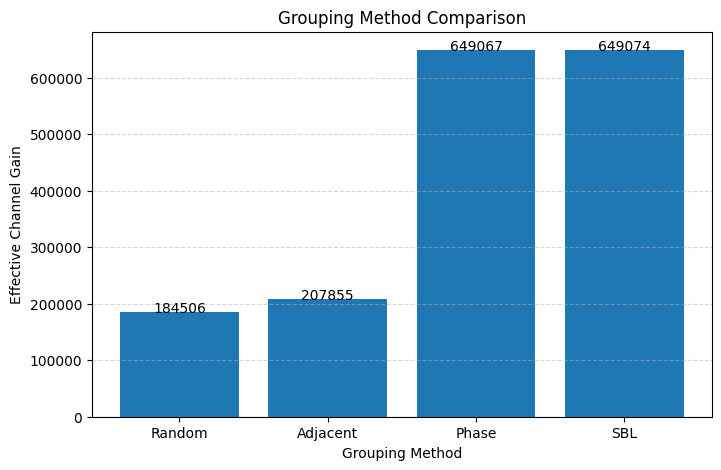

In [6]:
import matplotlib.pyplot as plt

methods = [
    "Random",
    "Adjacent",
    "Phase",
    "SBL"
]

gains = [
    184505.61539511953,
    207854.69507877014,
    649066.8657071844,
    649073.7489700904
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    methods,
    gains
)

plt.ylabel("Effective Channel Gain")
plt.xlabel("Grouping Method")
plt.title("Grouping Method Comparison")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha='center'
    )

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.savefig(
    "../results/figures/grouping_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()